# Report Figures Generation
The following figures are generated dynamically from the validation predictions CSV file, utilizing granular per-query metrics and raw similarity scores.

In [1]:
# === GLOBAL PLOTTING CONFIGURATIONS ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_theme(style="whitegrid")

# Set professional typography and sizes
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 14,
    'figure.autolayout': True
})

# Create outputs figures directory if it doesn't exist
os.makedirs("../outputs/figures", exist_ok=True)
print("✅ Global plotting styles configured and figures directory verified.")

✅ Global plotting styles configured and figures directory verified.


✅ Saved Figure 1 to ../outputs/figures/baseline_retrieval_showdown.png


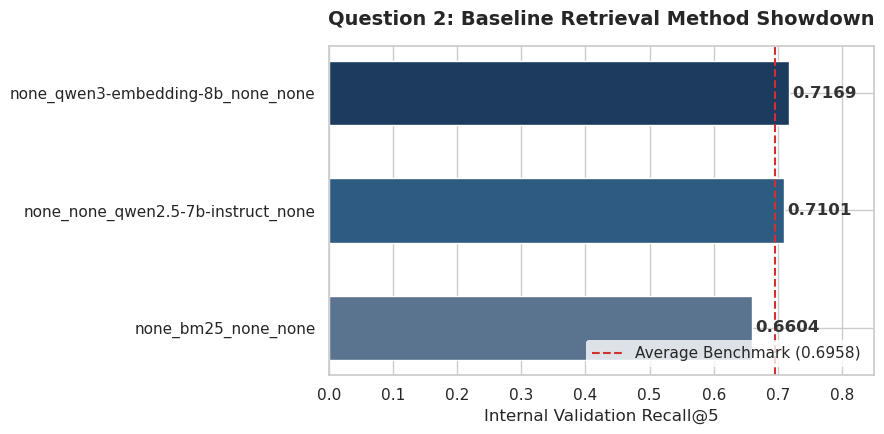

In [2]:
# === FIGURE 1: BASELINE RETRIEVAL METHOD SHOWDOWN ===
# Design: Horizontal bar chart comparing baseline recall scores with average benchmark annotation

baselines = {
    'none_bm25_none_none': 0.6604,
    'none_none_qwen2.5-7b-instruct_none': 0.7101,
    'none_qwen3-embedding-8b_none_none': 0.7169
}

# Load to DataFrame and sort in ascending order
df_baselines = pd.DataFrame(list(baselines.items()), columns=['Method', 'Recall@5'])
df_baselines = df_baselines.sort_values(by='Recall@5', ascending=True)

plt.figure(figsize=(9, 4.5))

# Deep corporate blue/gray palette
colors = ['#5A738E', '#2E5B82', '#1C3B5E']
bars = plt.barh(df_baselines['Method'], df_baselines['Recall@5'], color=colors, height=0.55)

# Add benchmark average line
avg_benchmark = df_baselines['Recall@5'].mean()
plt.axvline(avg_benchmark, color='#D32F2F', linestyle='--', linewidth=1.5, 
            label=f'Average Benchmark ({avg_benchmark:.4f})')

# Annotate exact value at the tip of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
             va='center', ha='left', fontweight='semibold', color='#333333')

plt.title('Question 2: Baseline Retrieval Method Showdown', pad=15, fontweight='bold')
plt.xlabel('Internal Validation Recall@5')
plt.xlim(0.0, 0.85)
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Save figure
fig1_path = '../outputs/figures/baseline_retrieval_showdown.png'
plt.savefig(fig1_path, dpi=300)
print(f"✅ Saved Figure 1 to {fig1_path}")
plt.show()

✅ Saved Figure 2 to ../outputs/figures/hybrid_text_truncation_analysis.png


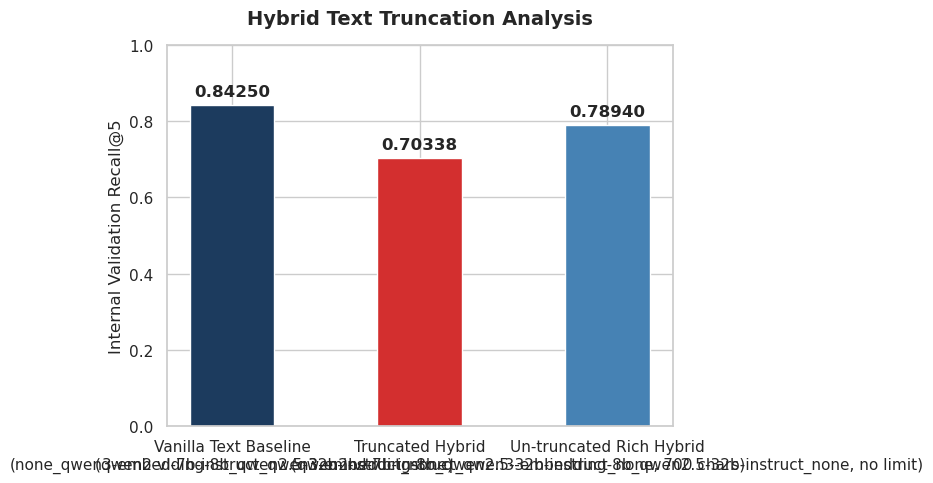

In [3]:
# === FIGURE 2: HYBRID TEXT TRUNCATION ANALYSIS ===
# Design: Column chart showing the trajectory of un-truncated rich text recovery vs truncation loss

categories = [
    'Vanilla Text Baseline\n(none_qwen3-embedding-8b_qwen2.5-32b-instruct_none)',
    'Truncated Hybrid\n(qwen2-vl-7b-instruct_qwen3-embedding-8b_qwen2.5-32b-instruct_none, 700 chars)',
    'Un-truncated Rich Hybrid\n(qwen2-vl-7b-instruct_qwen3-embedding-8b_qwen2.5-32b-instruct_none, no limit)'
]
scores = [0.8425, 0.70338, 0.7894]

plt.figure(figsize=(9, 5))

# Red/Orange highlight to show the performance drop due to truncation
colors = ['#1C3B5E', '#D32F2F', '#4682B4']
bars = plt.bar(categories, scores, color=colors, width=0.45)

# Annotate heights
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.015, f'{height:.5f}',
             va='bottom', ha='center', fontweight='semibold')

plt.title('Hybrid Text Truncation Analysis', pad=15, fontweight='bold')
plt.ylabel('Internal Validation Recall@5')
plt.ylim(0.0, 1.0)
plt.tight_layout()

# Save figure
fig2_path = '../outputs/figures/hybrid_text_truncation_analysis.png'
plt.savefig(fig2_path, dpi=300)
print(f"✅ Saved Figure 2 to {fig2_path}")
plt.show()

✅ Saved Figure 3 to ../outputs/figures/multimodal_vs_text_translation.png


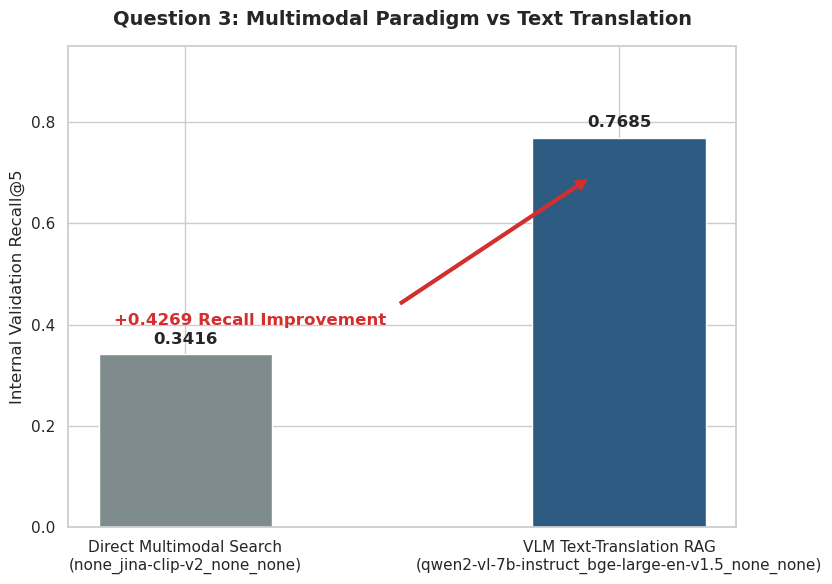

In [4]:
# === FIGURE 3: MULTIMODAL PARADIGM VS TEXT TRANSLATION ===
# Design: Column chart showing modality gap with red arrow annotation demonstrating performance gain

labels = [
    'Direct Multimodal Search\n(none_jina-clip-v2_none_none)', 
    'VLM Text-Translation RAG\n(qwen2-vl-7b-instruct_bge-large-en-v1.5_none_none)'
]
scores = [0.3416, 0.7685]

plt.figure(figsize=(8.5, 6))

# Neutral gray vs Deep blue contrast
colors = ['#7F8C8D', '#2E5B82']
bars = plt.bar(labels, scores, color=colors, width=0.4)

# Annotate bar values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.015, f'{height:.4f}',
             va='bottom', ha='center', fontweight='semibold')

# Add red highlight arrow showing performance gain
plt.annotate(
    '+0.4269 Recall Improvement',
    xy=(0.95, 0.70),
    xytext=(0.15, 0.40),
    arrowprops=dict(facecolor='#D32F2F', edgecolor='#D32F2F', shrink=0.05, width=2, headwidth=8, headlength=8),
    fontsize=12,
    fontweight='bold',
    color='#D32F2F',
    ha='center'
)

plt.title('Question 3: Multimodal Paradigm vs Text Translation', pad=15, fontweight='bold')
plt.ylabel('Internal Validation Recall@5')
plt.ylim(0.0, 0.95)
plt.tight_layout()

# Save figure
fig3_path = '../outputs/figures/multimodal_vs_text_translation.png'
plt.savefig(fig3_path, dpi=300)
print(f"✅ Saved Figure 3 to {fig3_path}")
plt.show()

In [5]:
# === LOAD VALIDATION DATA ===
val_path = "../outputs/validation/val_none_bm25_none_none.csv" # ANCHOR: Change the validation path that you want to investigate here!
df_val = pd.read_csv(val_path)
print(f"Loaded {len(df_val)} validation samples from {val_path}")
print(df_val.head(2))

Loaded 2054 validation samples from ../outputs/validation/val_none_bm25_none_none.csv
   q_id                      gold_quotes target_quotes  \
0     0   image5 text3 text4 text9 text2  image5 text6   
1     1  image1 text4 text9 text6 image2  image1 text4   

                                            scores  recall  mrr  hit_rate_k  \
0     9.053613 4.433259 4.326751 4.076404 3.811138     0.5  1.0         1.0   
1  14.562340 12.783446 10.034848 7.252416 7.052600     1.0  1.0         1.0   

   hit_rate_1  
0         1.0  
1         1.0  


### Figure 4: Confidence Distribution (Correct vs. Incorrect Rank-1 Predictions)

**Purpose:** Visualize the calibration of the retriever by showing if the model assigns higher confidence scores to correct predictions compared to incorrect ones.

**How to Interpret:** If the retriever is well-calibrated, the distribution of scores for correct predictions (Hit@1 = 1.0) will be shifted to the right, showing higher confidence, while incorrect predictions (Hit@1 = 0.0) will be centered on lower scores. An overlapping or identical distribution means the model cannot distinguish its own correct answers from incorrect ones.

✅ Saved Figure 4 to ../outputs/figures/confidence_distribution.png


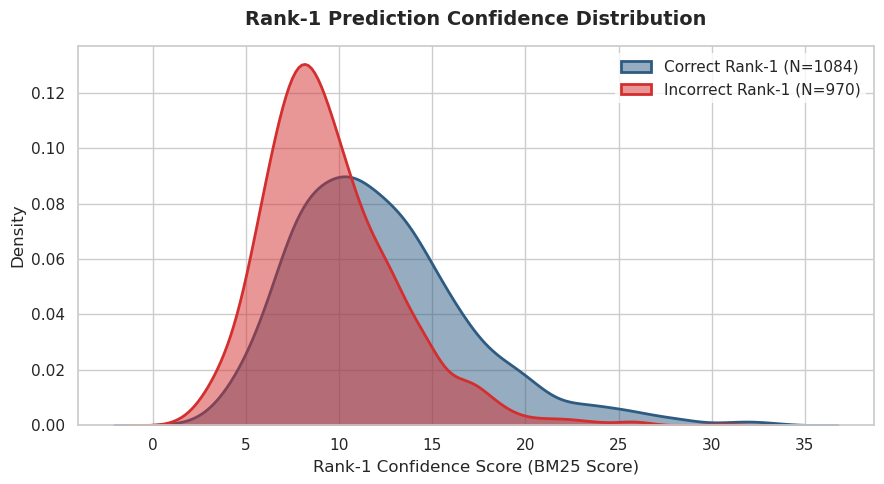

In [6]:
# === FIGURE 4: CONFIDENCE DISTRIBUTION ===
plt.figure(figsize=(9, 5))

# Separate correct vs incorrect based on hit_rate_1
correct_scores = []
incorrect_scores = []

for _, row in df_val.iterrows():
    try:
        scores = [float(s) for s in str(row['scores']).split()]
        if not scores:
            continue
        max_score = scores[0]
        if row['hit_rate_1'] == 1.0:
            correct_scores.append(max_score)
        else:
            incorrect_scores.append(max_score)
    except:
        continue

# Plot Kernel Density Estimate (KDE)
if correct_scores:
    sns.kdeplot(correct_scores, fill=True, color='#2E5B82', label=f'Correct Rank-1 (N={len(correct_scores)})', alpha=0.5, linewidth=2)
if incorrect_scores:
    sns.kdeplot(incorrect_scores, fill=True, color='#D32F2F', label=f'Incorrect Rank-1 (N={len(incorrect_scores)})', alpha=0.5, linewidth=2)

plt.title('Rank-1 Prediction Confidence Distribution', pad=15, fontweight='bold')
plt.xlabel('Rank-1 Confidence Score (BM25 Score)')
plt.ylabel('Density')
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

fig4_path = '../outputs/figures/confidence_distribution.png'
plt.savefig(fig4_path, dpi=300)
print(f"✅ Saved Figure 4 to {fig4_path}")
plt.show()

### Figure 5: Confidence Score Gap vs. Accuracy

**Purpose:** Analyze if the model's confidence margin (the difference between the Rank 1 and Rank 2 score) correlates with actual query accuracy.

**How to Interpret:** If a larger gap between the top prediction and the runner-up indicates higher accuracy, it suggests that the model's confidence margin is a reliable signal of correctness. We bin the score gaps and plot the mean Hit Rate@1 for each bin.

✅ Saved Figure 5 to ../outputs/figures/score_gap_vs_accuracy.png


/tmp/ipykernel_1514791/717674133.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_gap.groupby('gap_bin')['accuracy'].agg(['mean', 'count']).reset_index()


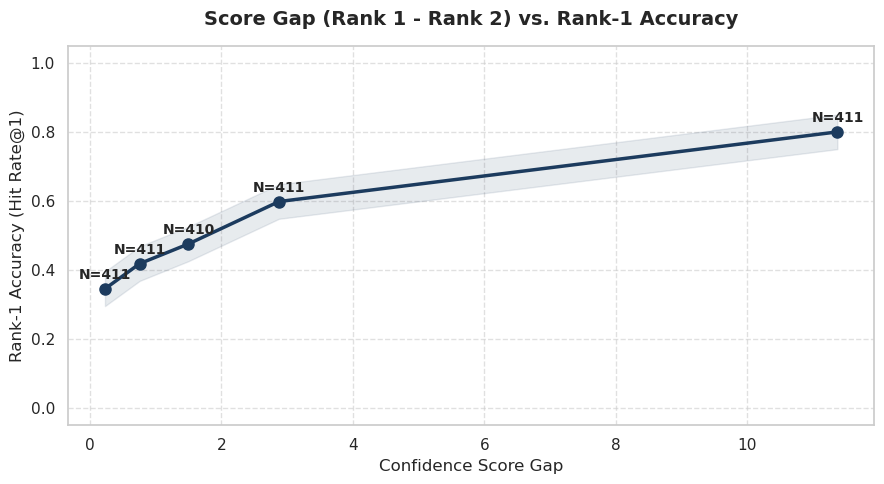

In [7]:
# === FIGURE 5: SCORE GAP VS ACCURACY ===
gaps = []
accuracy = []

for _, row in df_val.iterrows():
    try:
        scores = [float(s) for s in str(row['scores']).split()]
        if len(scores) < 2:
            continue
        gap = scores[0] - scores[1]
        gaps.append(gap)
        accuracy.append(row['hit_rate_1'])
    except:
        continue

df_gap = pd.DataFrame({'gap': gaps, 'accuracy': accuracy})

# Bin the gaps into 5 quantiles or equal-width bins
df_gap['gap_bin'] = pd.qcut(df_gap['gap'], q=5, duplicates='drop')

# Calculate mean accuracy per bin
bin_stats = df_gap.groupby('gap_bin')['accuracy'].agg(['mean', 'count']).reset_index()
bin_stats['bin_center'] = bin_stats['gap_bin'].apply(lambda x: x.mid)

plt.figure(figsize=(9, 5))
# Plot a trendline with markers
plt.plot(bin_stats['bin_center'], bin_stats['mean'], marker='o', linewidth=2.5, color='#1C3B5E', markersize=8)
plt.fill_between(bin_stats['bin_center'], bin_stats['mean'] - 0.05, bin_stats['mean'] + 0.05, color='#1C3B5E', alpha=0.1)

# Annotate sample count per bin
for idx, row_stat in bin_stats.iterrows():
    plt.text(row_stat['bin_center'], row_stat['mean'] + 0.02, f"N={int(row_stat['count'])}", 
             ha='center', va='bottom', fontsize=10, fontweight='semibold')

plt.title('Score Gap (Rank 1 - Rank 2) vs. Rank-1 Accuracy', pad=15, fontweight='bold')
plt.xlabel('Confidence Score Gap')
plt.ylabel('Rank-1 Accuracy (Hit Rate@1)')
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

fig5_path = '../outputs/figures/score_gap_vs_accuracy.png'
plt.savefig(fig5_path, dpi=300)
print(f"✅ Saved Figure 5 to {fig5_path}")
plt.show()

### Figure 6: Correct Answer Position (Rank Decay)

**Purpose:** Display the exact rank position where the correct answer was retrieved.

**How to Interpret:** A high-performing retriever should place the correct document at Rank 1. This decay curve shows how often the correct document is found at Rank 1 vs. Rank 2, 3, 4, 5, or if it was not retrieved in the Top-5 at all. The 'Not Found' bar represents `1.0 - Hit Rate@5`.

✅ Saved Figure 6 to ../outputs/figures/position_decay.png


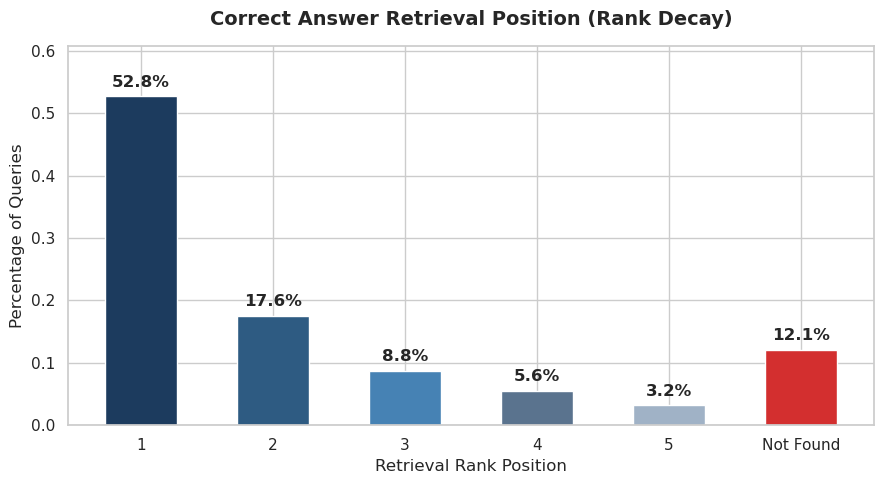

In [8]:
# === FIGURE 6: POSITION DECAY ===
positions = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 'Not Found': 0}

for _, row in df_val.iterrows():
    pred_ids = str(row['gold_quotes']).split()
    target_ids = str(row['target_quotes']).split()
    
    # Find rank of first target match
    found = False
    for rank, pred_id in enumerate(pred_ids[:5], 1):
        if pred_id in target_ids:
            positions[rank] += 1
            found = True
            break
    if not found:
        positions['Not Found'] += 1

total = sum(positions.values())
pos_pcts = {k: v / total for k, v in positions.items()}

plt.figure(figsize=(9, 5))
colors = ['#1C3B5E', '#2E5B82', '#4682B4', '#5A738E', '#A0B2C6', '#D32F2F']
bars = plt.bar([str(k) for k in pos_pcts.keys()], pos_pcts.values(), color=colors, width=0.55)

# Annotate percentages
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height*100:.1f}%',
             va='bottom', ha='center', fontweight='semibold')

plt.title('Correct Answer Retrieval Position (Rank Decay)', pad=15, fontweight='bold')
plt.xlabel('Retrieval Rank Position')
plt.ylabel('Percentage of Queries')
plt.ylim(0.0, max(pos_pcts.values()) + 0.08)
plt.tight_layout()

fig6_path = '../outputs/figures/position_decay.png'
plt.savefig(fig6_path, dpi=300)
print(f"✅ Saved Figure 6 to {fig6_path}")
plt.show()

### Figure 7: Retrieval Metric Trade-off Showdown

**Purpose:** Compare all key retrieval metrics (Recall@5, MRR@5, Hit Rate@5, and Hit Rate@1) side-by-side to understand the macro performance of the retriever.

**How to Interpret:** Recall@5 shows what percentage of all correct quotes were retrieved. Hit Rate@5 shows the percentage of queries where *at least one* correct quote was found in the top-5. MRR@5 shows the rank-weighted performance. Hit Rate@1 is the percentage of queries where the top recommendation was correct.

✅ Saved Figure 7 to ../outputs/figures/retrieval_metrics_summary.png


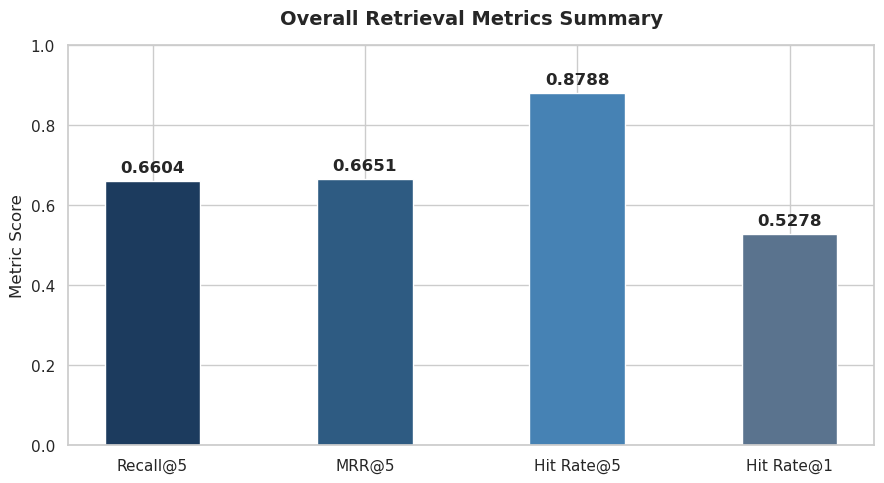

In [9]:
# === FIGURE 7: METRICS COMPARISON ===
metrics = {
    'Recall@5': df_val['recall'].mean(),
    'MRR@5': df_val['mrr'].mean(),
    'Hit Rate@5': df_val['hit_rate_k'].mean(),
    'Hit Rate@1': df_val['hit_rate_1'].mean()
}

plt.figure(figsize=(9, 5))
colors = ['#1C3B5E', '#2E5B82', '#4682B4', '#5A738E']
bars = plt.bar(metrics.keys(), metrics.values(), color=colors, width=0.45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.015, f'{height:.4f}',
             va='bottom', ha='center', fontweight='semibold')

plt.title('Overall Retrieval Metrics Summary', pad=15, fontweight='bold')
plt.ylabel('Metric Score')
plt.ylim(0.0, 1.0)
plt.tight_layout()

fig7_path = '../outputs/figures/retrieval_metrics_summary.png'
plt.savefig(fig7_path, dpi=300)
print(f"✅ Saved Figure 7 to {fig7_path}")
plt.show()

### Figure 8: Modality Preference Analysis (Text vs. Image Retrieval)

**Purpose:** Analyze the retriever's preference for text vs. image evidence compared to the ground-truth distribution in the validation dataset, and track how different models shift this modality bias.

**How to Interpret:** The first group shows the distribution of retrieved evidence quotes (Text vs. Image) for BM25, Dense Hybrid, and the LLM Reranker against the ground truth. The second group shows the Recall@5 performance broken down by modality across all three models.

✅ Saved Figure 8 to ../outputs/figures/modality_preference.png


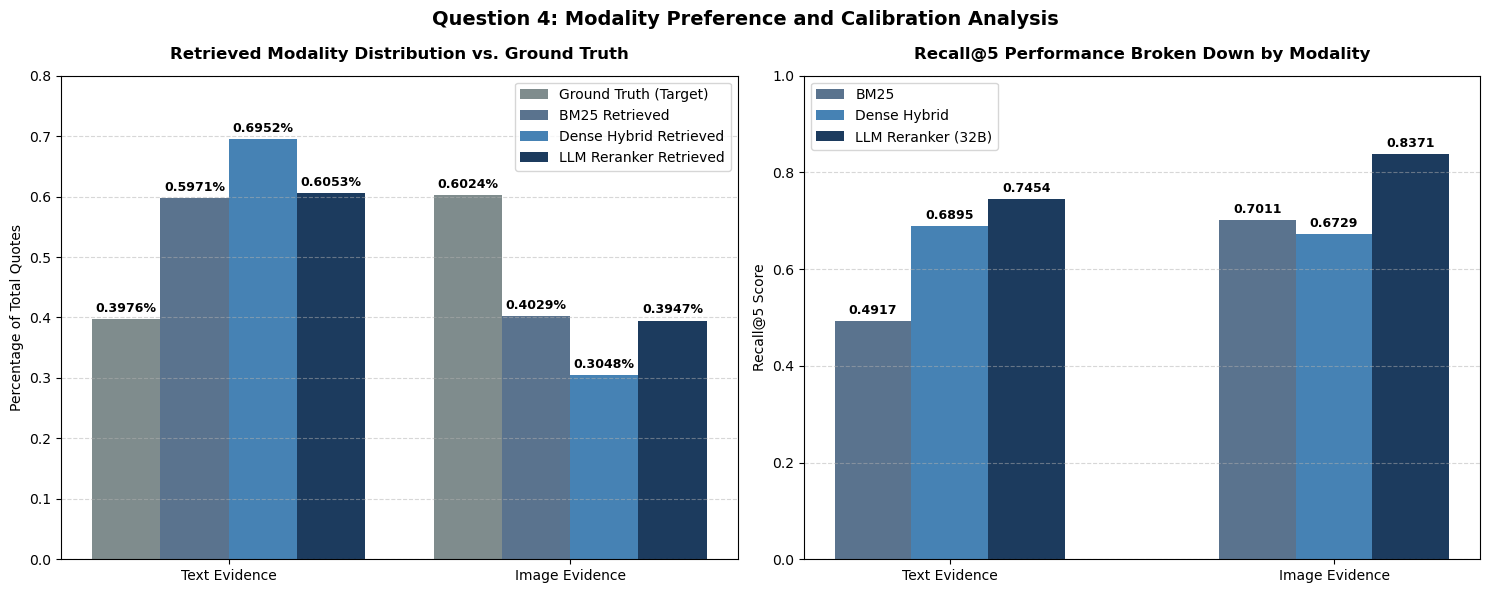

In [2]:
# === FIGURE 8: MODALITY PREFERENCE PLOT ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataframes
bm25_path = "../outputs/validation/val_none_bm25_none_none.csv"
dense_path = "../outputs/validation/val_none_hybrid(qwen3-embedding-8b + bge-m3)_none_none.csv"
llm_path = "../outputs/validation/val_none_hybrid(qwen3-embedding-8b + bge-m3)_qwen2.5-32b-instruct_none_12.csv"

df_bm25 = pd.read_csv(bm25_path)
df_dense = pd.read_csv(dense_path)
df_llm = pd.read_csv(llm_path)

# Build ground-truth target mapping from BM25 file
target_map = df_bm25.set_index('q_id')['target_quotes'].to_dict()

def compute_modality_stats(df):
    ret_text, ret_img = 0, 0
    tgt_text, tgt_img = 0, 0
    hits_text, hits_img = 0, 0
    
    for _, row in df.iterrows():
        qid = row['q_id']
        preds = str(row['gold_quotes']).split()
        targets = str(target_map[qid]).split()
        
        for p in preds:
            if p.startswith('text'): ret_text += 1
            elif p.startswith('image'): ret_img += 1
            
        for t in targets:
            if t.startswith('text'):
                tgt_text += 1
                if t in preds: hits_text += 1
            elif t.startswith('image'):
                tgt_img += 1
                if t in preds: hits_img += 1
                
    ret_total = ret_text + ret_img
    tgt_total = tgt_text + tgt_img
    
    return {
        'ret_text_pct': ret_text / ret_total,
        'ret_img_pct': ret_img / ret_total,
        'tgt_text_pct': tgt_text / tgt_total,
        'tgt_img_pct': tgt_img / tgt_total,
        'recall_text': hits_text / tgt_text,
        'recall_img': hits_img / tgt_img
    }

stats_bm25 = compute_modality_stats(df_bm25)
stats_dense = compute_modality_stats(df_dense)
stats_llm = compute_modality_stats(df_llm)

# Plotting retrieved distribution vs target
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Distribution of retrieved quotes
categories = ['Text Evidence', 'Image Evidence']
x = np.arange(len(categories))
width = 0.2

axes[0].bar(x - 1.5*width, [stats_bm25['tgt_text_pct'], stats_bm25['tgt_img_pct']], width, label='Ground Truth (Target)', color='#7F8C8D')
axes[0].bar(x - 0.5*width, [stats_bm25['ret_text_pct'], stats_bm25['ret_img_pct']], width, label='BM25 Retrieved', color='#5A738E')
axes[0].bar(x + 0.5*width, [stats_dense['ret_text_pct'], stats_dense['ret_img_pct']], width, label='Dense Hybrid Retrieved', color='#4682B4')
axes[0].bar(x + 1.5*width, [stats_llm['ret_text_pct'], stats_llm['ret_img_pct']], width, label='LLM Reranker Retrieved', color='#1C3B5E')

axes[0].set_title('Retrieved Modality Distribution vs. Ground Truth', fontweight='bold', pad=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_ylabel('Percentage of Total Quotes')
axes[0].set_ylim(0, 0.8)
axes[0].legend(frameon=True)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# Annotate exact percentages on axes[0]
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.4f%%', padding=3, fontsize=9, fontweight='semibold')

# Subplot 2: Recall@5 by Modality
axes[1].bar(x - width, [stats_bm25['recall_text'], stats_bm25['recall_img']], width, label='BM25', color='#5A738E')
axes[1].bar(x, [stats_dense['recall_text'], stats_dense['recall_img']], width, label='Dense Hybrid', color='#4682B4')
axes[1].bar(x + width, [stats_llm['recall_text'], stats_llm['recall_img']], width, label='LLM Reranker (32B)', color='#1C3B5E')

axes[1].set_title('Recall@5 Performance Broken Down by Modality', fontweight='bold', pad=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel('Recall@5 Score')
axes[1].set_ylim(0, 1.0)
axes[1].legend(frameon=True)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

# Annotate exact values on axes[1]
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.4f', padding=3, fontsize=9, fontweight='semibold')

plt.suptitle('Question 4: Modality Preference and Calibration Analysis', fontweight='bold', fontsize=14, y=0.98)
plt.tight_layout()

fig8_path = '../outputs/figures/modality_preference.png'
plt.savefig(fig8_path, dpi=300)
print(f"✅ Saved Figure 8 to {fig8_path}")
plt.show()